Установка и базовая подготовка

In [1]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.master("local[*]").getOrCreate()
df = spark.read.csv('iris.csv', inferSchema=True, header=True)

In [2]:
df.head(10)

[Row(sepal.length=5.1, sepal.width=3.5, petal.length=1.4, petal.width=0.2, variety='Setosa'),
 Row(sepal.length=4.9, sepal.width=3.0, petal.length=1.4, petal.width=0.2, variety='Setosa'),
 Row(sepal.length=4.7, sepal.width=3.2, petal.length=1.3, petal.width=0.2, variety='Setosa'),
 Row(sepal.length=4.6, sepal.width=3.1, petal.length=1.5, petal.width=0.2, variety='Setosa'),
 Row(sepal.length=5.0, sepal.width=3.6, petal.length=1.4, petal.width=0.2, variety='Setosa'),
 Row(sepal.length=5.4, sepal.width=3.9, petal.length=1.7, petal.width=0.4, variety='Setosa'),
 Row(sepal.length=4.6, sepal.width=3.4, petal.length=1.4, petal.width=0.3, variety='Setosa'),
 Row(sepal.length=5.0, sepal.width=3.4, petal.length=1.5, petal.width=0.2, variety='Setosa'),
 Row(sepal.length=4.4, sepal.width=2.9, petal.length=1.4, petal.width=0.2, variety='Setosa'),
 Row(sepal.length=4.9, sepal.width=3.1, petal.length=1.5, petal.width=0.1, variety='Setosa')]

In [3]:
df.show()

+------------+-----------+------------+-----------+-------+
|sepal.length|sepal.width|petal.length|petal.width|variety|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|
|         5.4|        3.9|         1.7|        0.4| Setosa|
|         4.6|        3.4|         1.4|        0.3| Setosa|
|         5.0|        3.4|         1.5|        0.2| Setosa|
|         4.4|        2.9|         1.4|        0.2| Setosa|
|         4.9|        3.1|         1.5|        0.1| Setosa|
|         5.4|        3.7|         1.5|        0.2| Setosa|
|         4.8|        3.4|         1.6|        0.2| Setosa|
|         4.8|        3.0|         1.4|        0.1| Setosa|
|         4.3|        3.0|         1.1| 

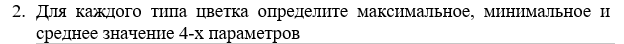

In [4]:
df.groupBy("variety").agg(F.min("`sepal.length`"), F.max("`sepal.length`"), F.avg("`sepal.length`")).show()


+----------+-----------------+-----------------+-----------------+
|   variety|min(sepal.length)|max(sepal.length)|avg(sepal.length)|
+----------+-----------------+-----------------+-----------------+
| Virginica|              4.9|              7.9|6.587999999999998|
|    Setosa|              4.3|              5.8|5.005999999999999|
|Versicolor|              4.9|              7.0|            5.936|
+----------+-----------------+-----------------+-----------------+



In [5]:
df.groupBy("variety").agg(F.min('`sepal.width`'), F.max('`sepal.width`'), F.avg('`sepal.width`')).show()

+----------+----------------+----------------+------------------+
|   variety|min(sepal.width)|max(sepal.width)|  avg(sepal.width)|
+----------+----------------+----------------+------------------+
| Virginica|             2.2|             3.8|2.9739999999999998|
|    Setosa|             2.3|             4.4| 3.428000000000001|
|Versicolor|             2.0|             3.4|2.7700000000000005|
+----------+----------------+----------------+------------------+



In [6]:
df.groupBy("variety").agg(F.min("`petal.length`"), F.max("`petal.length`"), F.avg("`petal.length`")).show()

+----------+-----------------+-----------------+------------------+
|   variety|min(petal.length)|max(petal.length)| avg(petal.length)|
+----------+-----------------+-----------------+------------------+
| Virginica|              4.5|              6.9|             5.552|
|    Setosa|              1.0|              1.9|1.4620000000000002|
|Versicolor|              3.0|              5.1|              4.26|
+----------+-----------------+-----------------+------------------+



In [7]:
df.groupBy("variety").agg(F.min("`petal.width`"), F.max("`petal.width`"), F.avg("`petal.width`")).show()

+----------+----------------+----------------+------------------+
|   variety|min(petal.width)|max(petal.width)|  avg(petal.width)|
+----------+----------------+----------------+------------------+
| Virginica|             1.4|             2.5|             2.026|
|    Setosa|             0.1|             0.6|0.2459999999999999|
|Versicolor|             1.0|             1.8|1.3259999999999998|
+----------+----------------+----------------+------------------+



3.	Визуализируйте точечный график (plt.scatter) по каждой паре параметров

In [8]:
df.plot.scatter(x='sepal.width', y='sepal.length')

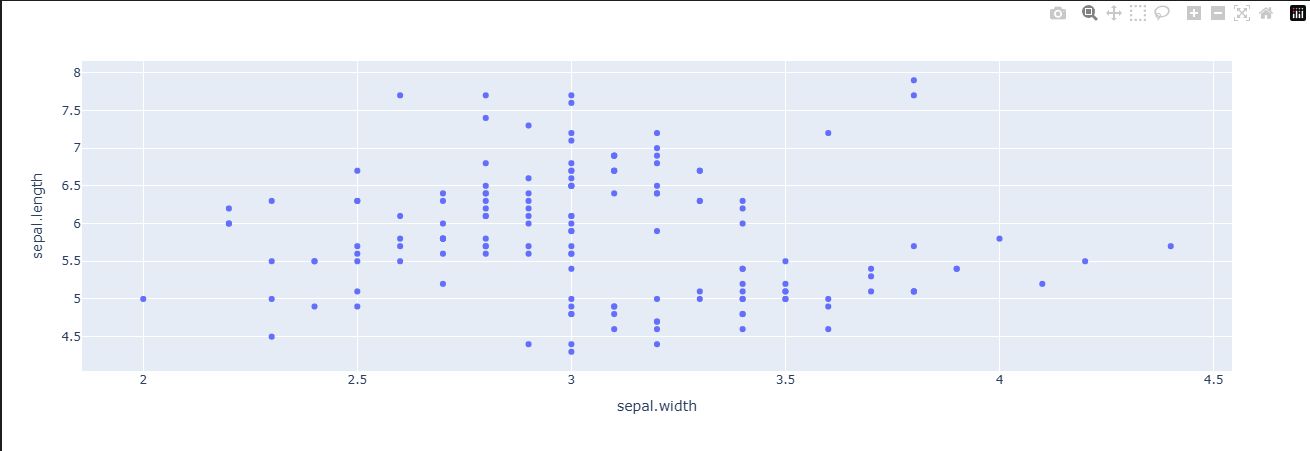

In [9]:
df.plot.scatter(x='sepal.width', y='petal.length')

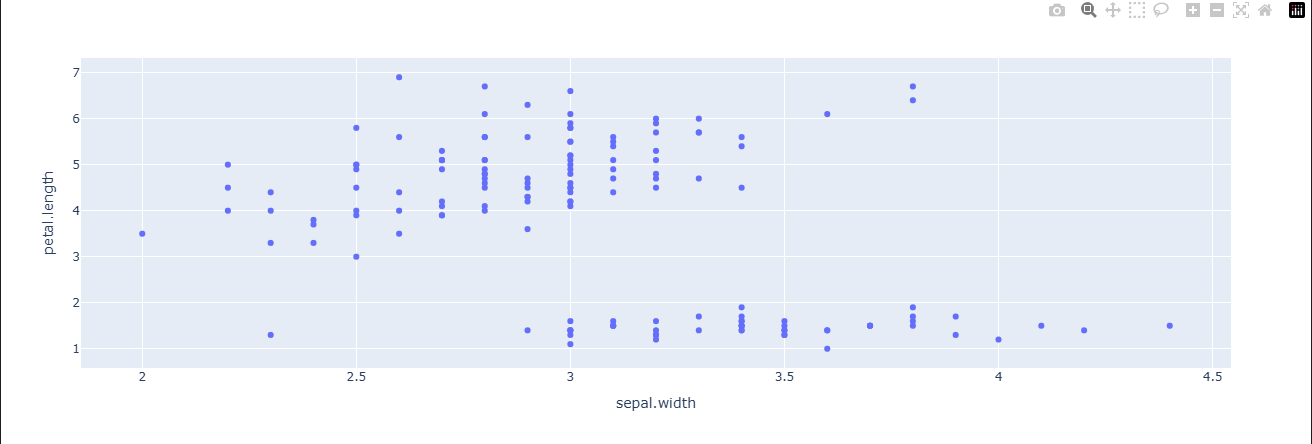

In [10]:
df.plot.scatter(x='sepal.width', y='petal.width')

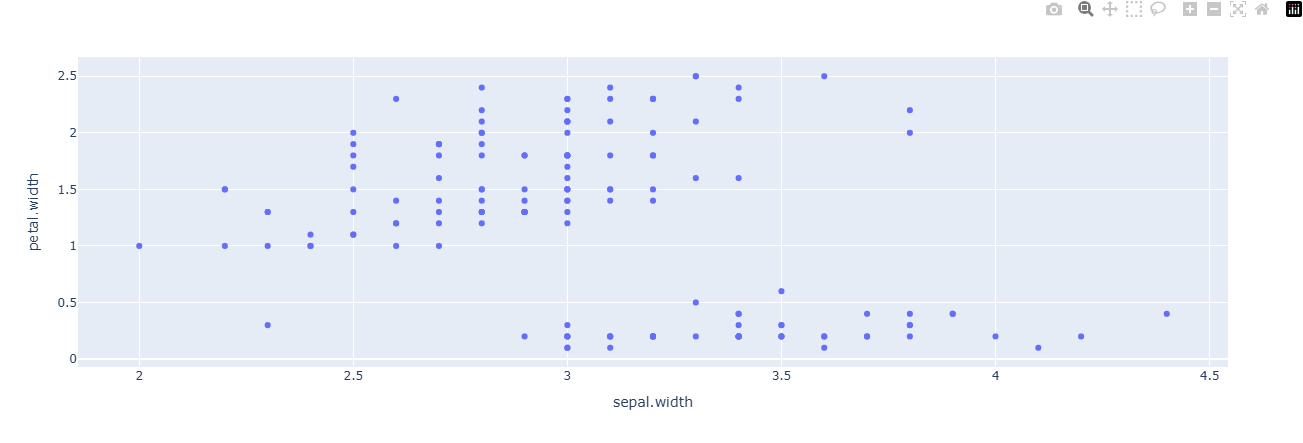

In [11]:
df.plot.scatter(x='petal.length', y='sepal.length')

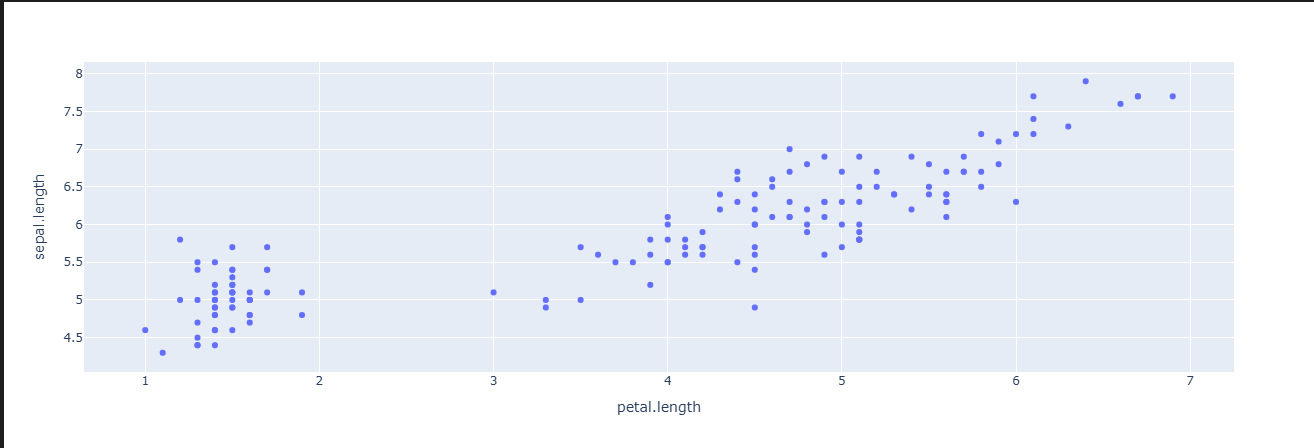

In [12]:
df.plot.scatter(x='petal.length', y='petal.width')

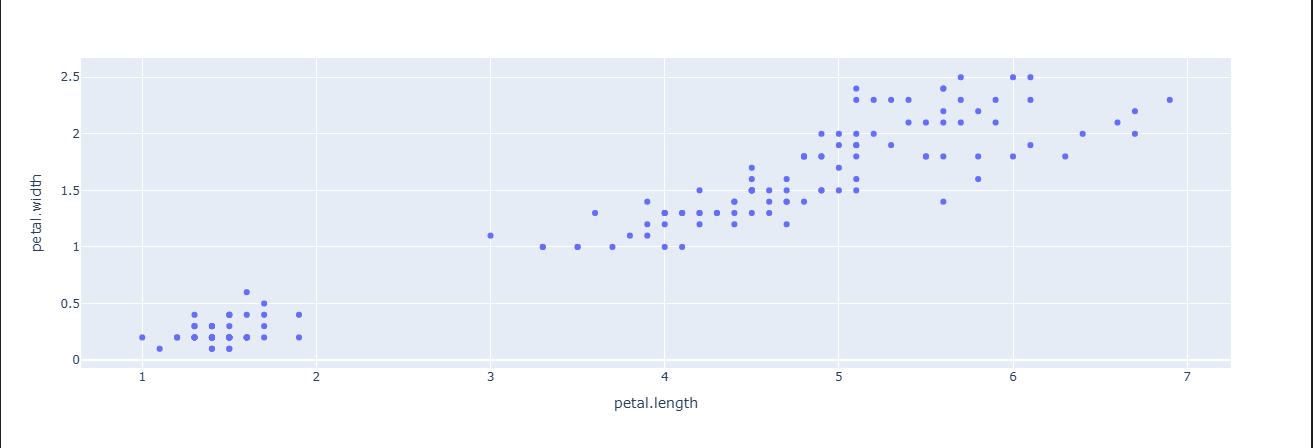

In [13]:
df.plot.scatter(x='petal.width', y='sepal.length')

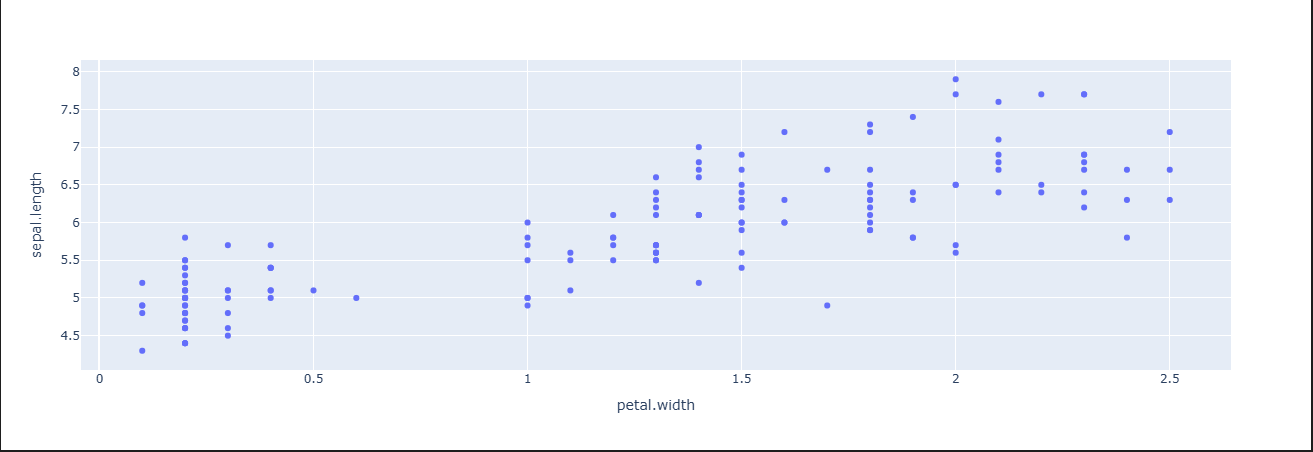

4.	Попробуйте отделить какой-нить тип цветка от всех остальных (сформулируйте правило на основе диаграммы - ЕСЛИ ЗНАЧЕНИЕ ПАРАМЕТРА X БОЛЬШЕ/МЕНЬШЕ Y, ТО ЦВЕТОК СКОРЕЕ ВСЕГО ОТНОСИТСЯ/НЕ ОТНОСИТСЯ К ТИПУ Z)

In [ ]:
df = df.withColumn("check", F.when( (F.col("`petal.width`") <= 0.75) & (F.col("`petal.length`") <= 2),  "Setosa").otherwise("Not setosa"))
df.show(10)

50
+------------+-----------+------------+-----------+----------+----------+
|sepal.length|sepal.width|petal.length|petal.width|   variety|     check|
+------------+-----------+------------+-----------+----------+----------+
|         5.1|        3.5|         1.4|        0.2|    Setosa|    Setosa|
|         4.9|        3.0|         1.4|        0.2|    Setosa|    Setosa|
|         4.7|        3.2|         1.3|        0.2|    Setosa|    Setosa|
|         4.6|        3.1|         1.5|        0.2|    Setosa|    Setosa|
|         5.0|        3.6|         1.4|        0.2|    Setosa|    Setosa|
|         5.4|        3.9|         1.7|        0.4|    Setosa|    Setosa|
|         4.6|        3.4|         1.4|        0.3|    Setosa|    Setosa|
|         5.0|        3.4|         1.5|        0.2|    Setosa|    Setosa|
|         4.4|        2.9|         1.4|        0.2|    Setosa|    Setosa|
|         4.9|        3.1|         1.5|        0.1|    Setosa|    Setosa|
|         5.4|        3.7|         

In [20]:
count = df.filter(F.col("variety") == F.col("check")).count() + df.filter((F.col("variety") != "Setosa") & (F.col("check") == "Not setosa")).count()
print(count)
df.count()

150


150